<a href="https://colab.research.google.com/github/stephenfrein/vucsc8491/blob/main/Week3_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dimensionality Reduction

The **Curse of Dimensionality** refers to problems that come from having too many "dimensions" (think variables or columns) in your data.

In brief, those are:

* it's harder for data mining algorithms to find the "signal" (vs random noise) in your data
* algorithms that rely on similarity and difference perform poorly because data points become very sparse (far apart)
* it's resource-intensive to handle all of the variables computationally

What is "too many" dimensions?  A loose rule of thumb says you should have at least 5 examples (rows) for every column (dimension) in your data set.

# Random Noise Can Degrade Model Performance

Having many "noise" dimensions that add little predictive value can often harm model performance. Let's build a simple linear regression model and show how noisy dimensions impact its performance.

Simplest template for building and testing models:

1.   Get some data
2.   Break it randomly into two sets: some used for training and the rest used for tesing
3.   Build a model based on the training data only
4.   See how well its predictions correspond to the testing data that it has never seen before

The performance on the previously unseen testing data gives us an idea of how well the model matches the patterns in the world we want it to capture.



# Linear Regression Refresher

Linear regression draws a "line of best fit" through a cloud of data. It's a simple kind of model.

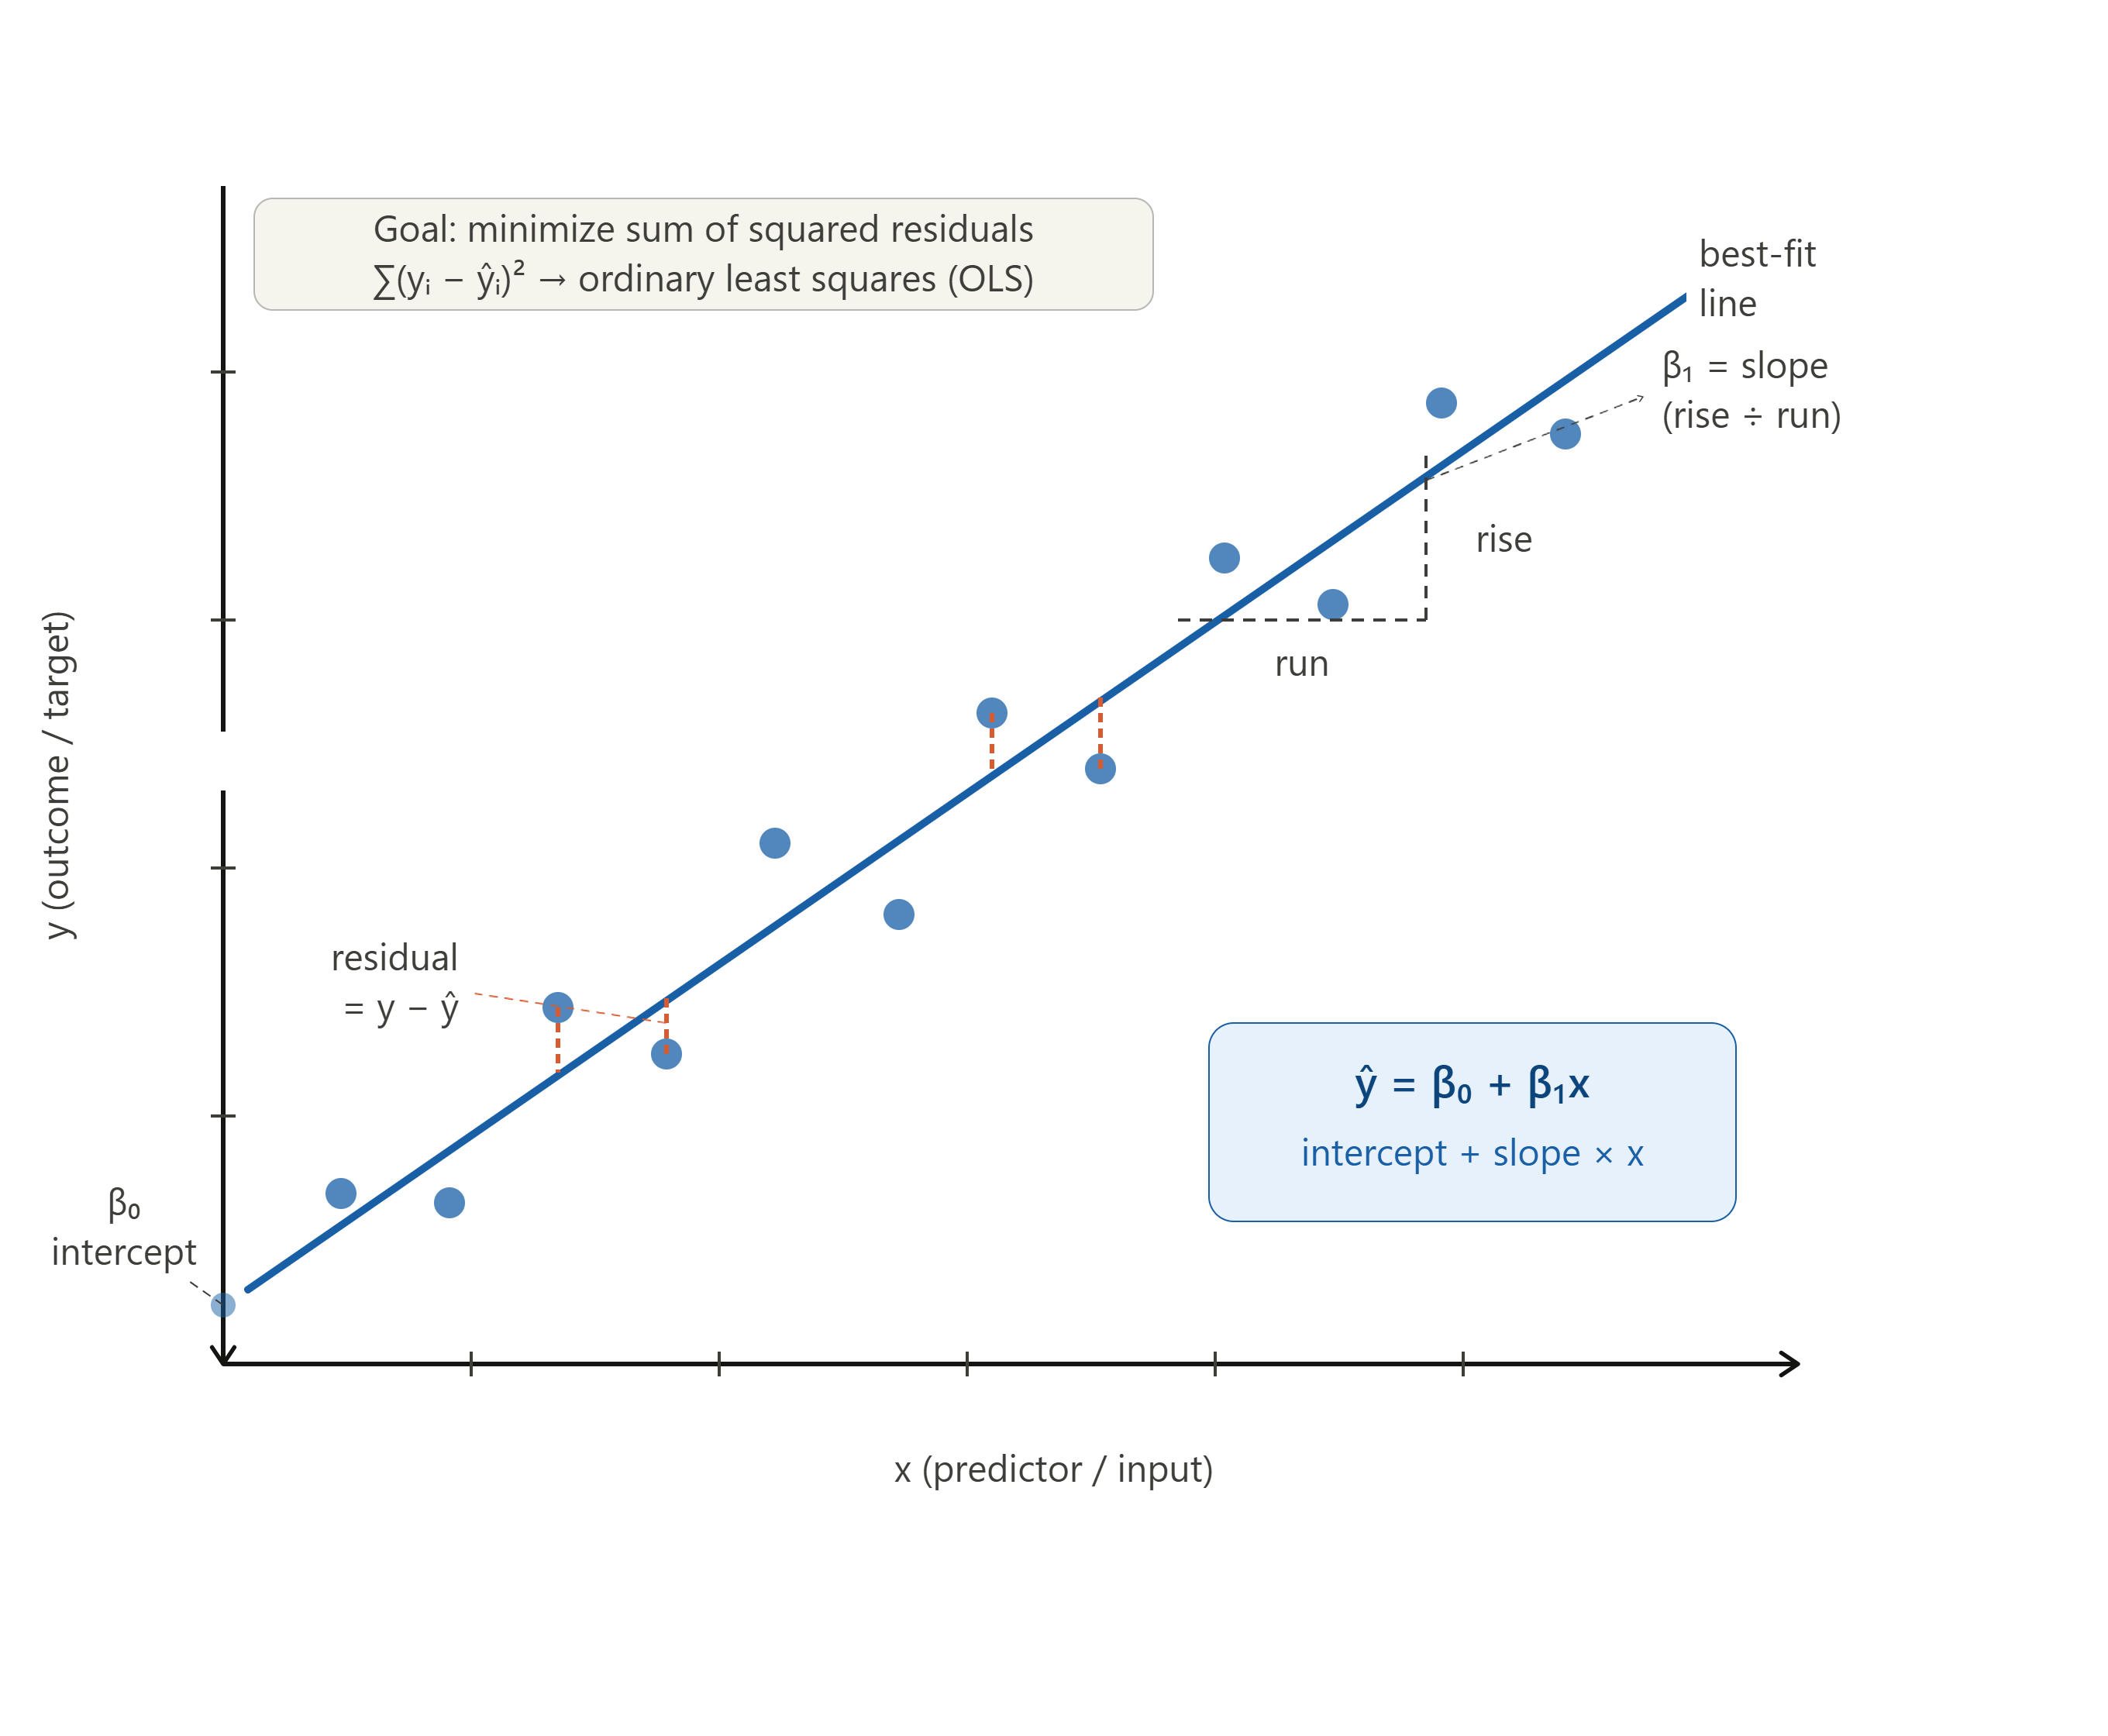

In [ ]:
## let's see impact of "noise" variables in linear regression ##
## look for the big picture here - we'll revisit linear regression later

import numpy as np
# sklearn is scikit-learn - we'll be using it to build ML models
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# set a random seed value for numpy - this makes our results repeatable
np.random.seed(123)
# number of test data points we'll create
n = 200

# create 200 (n) random numbers uniformly distributed between 0 and 10
# these will be our x values
x = np.random.uniform(0, 10, n)
# print first 5 values
print(x[:5])

# create corresponding y values using y = 3x + 5 as our formula
# add a little random noise to each y to simulate real data
# the random noise values have mean zero and standard deviation of 1
y = 3 * x + 5 + np.random.normal(0, 1, n)
# print first 5 values
print(y[:5])

# notice that the operation to create y is VECTORIZED
# because x is a numpy array (1-dimensional array of same type)
# it knew to multiply 3 by every item in x and then add the noise appropriately

## How Train/Test Split Works

(Later, we'll try a more complex verion of this approach called cross-validation.)

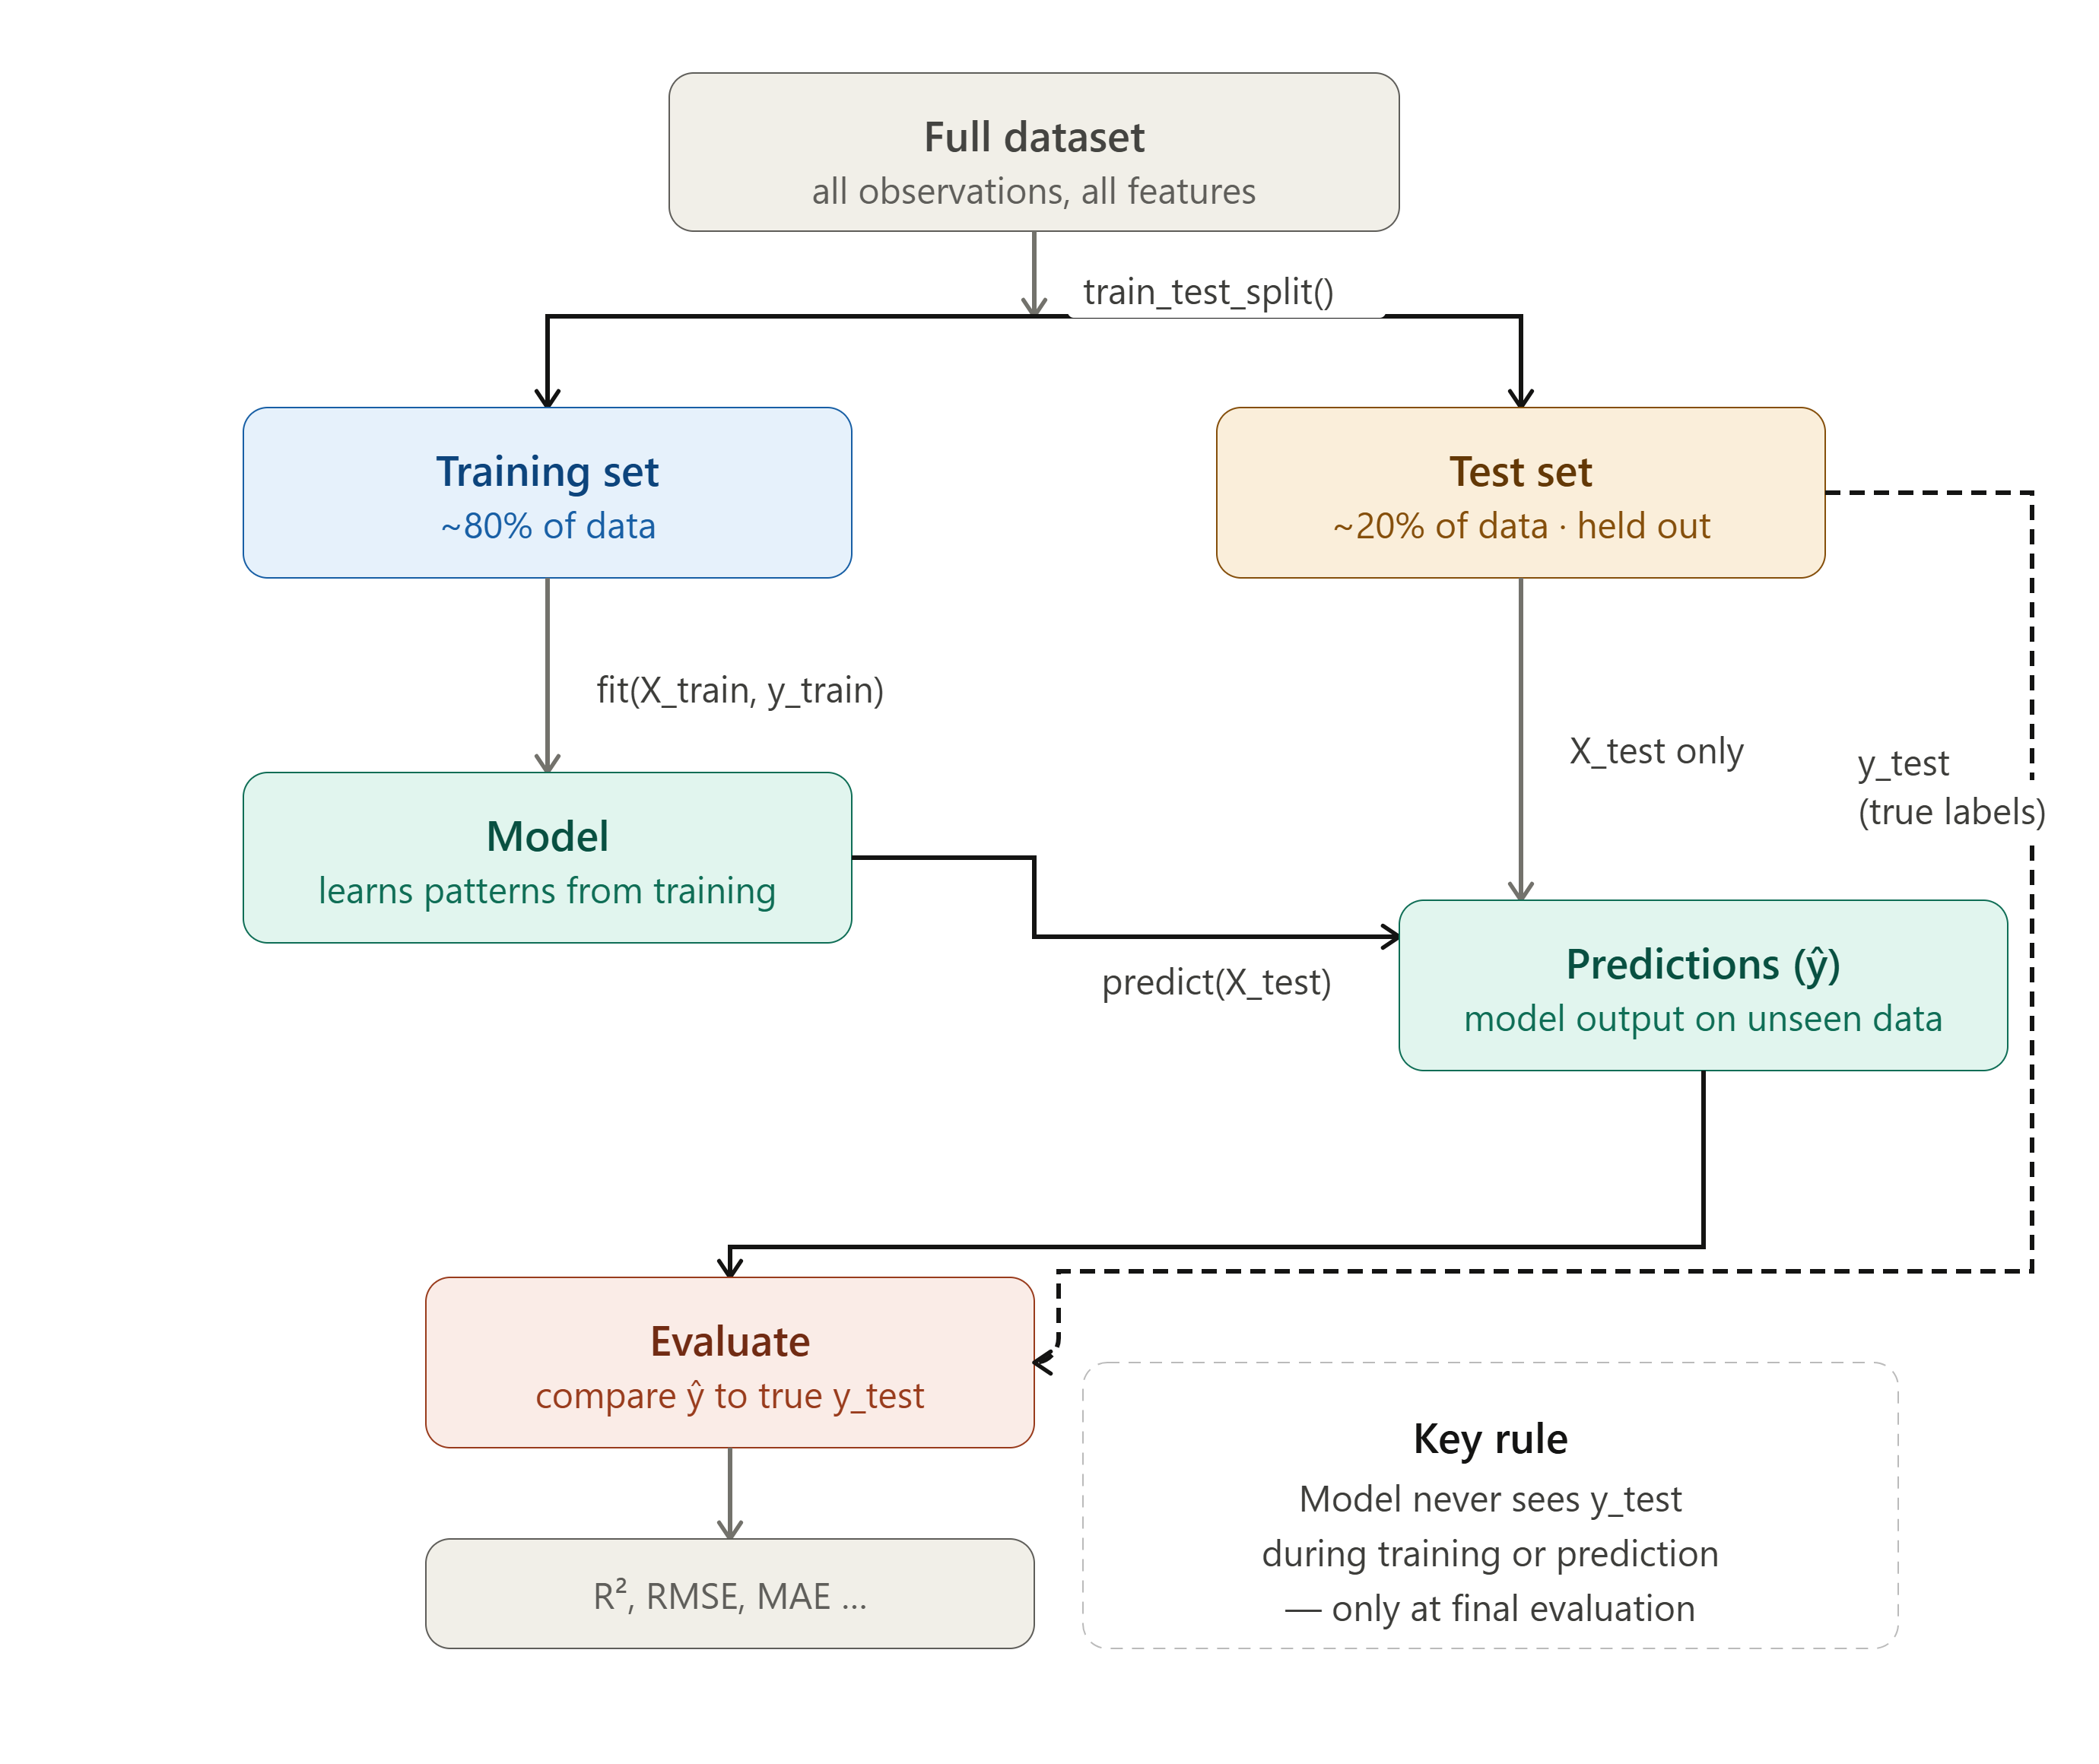

In [ ]:
# create "training" and "test" groups of x and y
# we use capital X rather than lowercase x because we usually have many predictor variables
# and it is common to refer to matrixes (table-like structures) with capital letters
# 20% of the data will be used for testing - could use some other proportion instead
# random_state makes results repeatable (initializes random # generator)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)

# now, we build a linear regression model on our training data
lr = LinearRegression()
# fit to the training data
lr.fit(X_train.reshape(-1, 1), y_train)

# see how well the same model predicts the test data
# r-squared score tells us how much variation in target variable (y)
# is explained by the predictor variable(s) - X_test in this case
r2_clean = r2_score(y_test, lr.predict(X_test.reshape(-1, 1)))
print('R-squared score on clean data is '+str(r2_clean))

In [ ]:
# create 100 noise variables (random, unrelated to y)
# the variables each have mean zero and standard deviation of 1
# we're asking for n rows and 100 different columns
noise = np.random.normal(0, 1, (n, 100))

# now combine the noisy, nonsense variables with our original x
X_noisy = np.column_stack([x, noise])

# create training and test data sets like before (using the noisy data)
X_train, X_test, y_train, y_test = train_test_split(X_noisy, y, test_size=0.2, random_state=123)

# fit a model on the noisy training data
lr.fit(X_train, y_train)

# see how well the noisy data model predicts the test data
r2_noisy = r2_score(y_test, lr.predict(X_test))
print('R-squared score on noisy data is '+str(r2_noisy))
print('Noisy data model is only ' + str(r2_noisy/r2_clean * 100) + '% as effective as clean data model')

## Increasing Dimensions Obscure "Near" and "Far"

In week 4, we'll look at clustering algorithms that rely on the idea of distace - which data points are "close" to each other (similar) and which are "far" away (dissimilar).

Increasing numbers of dimensions tend to make a point similarly "far" from all of its neighbors.

In [ ]:
import numpy as np
import pandas as pd

# set seed for reproducibility
np.random.seed(123)
# how many data points (rows)?
n_points = 100
# how many different dimensions (columns) per data point?
# we'll loop though many different possibilities
# each will result in a "table" with n_points rows and dimensions columns
dimensions = [2, 10, 50, 100, 500, 1000]

# print column headers in a formatted string (an "f-string")
# things like :>6 are formatting instructions - "right justify and pad 6 chars wide"
print(f"{'Dims':>6}  {'Min dist':>9}  {'Max dist':>9}  {'Min/Max':>8}  {'Std/Mean':>9}")
# prints 50 dashes as a separator
print("-" * 50)

# loop though all the dimension (# of columns) possibilities
for dims in dimensions:
    # create random data with that many dimensions (columns) and n_points rows
    data = np.random.uniform(0, 1, (n_points, dims))

    # used to store the distances between points
    distances = [] # this is a list
    # for each point (row)
    for i in range(n_points):
        # we'll be comparing it to all the points (rows) that come after it
        for j in range(i + 1, n_points):
            # capture all of the values in rows i and j
            point_i = data[i]
            point_j = data[j]

            # subtract each column one at a time
            differences = [] # this is a list
            # for each column in the data
            for k in range(len(point_i)):
                # find difference in value between the two rows
                differences.append(point_i[k] - point_j[k])

            # at this point, differences contains the results of substracting all
            # the values in one row from the corresponding values in the other row
            # square each difference
            squared_differences = []
            for diff in differences:
                squared_differences.append(diff ** 2)

            # add up all those squared differences
            sum_of_squares = 0
            for sq in squared_differences:
                sum_of_squares += sq

            # take the square root to get "straight-line" distance
            # this is Pythagorean theorem being extended to more than 2D
            d = np.sqrt(sum_of_squares)
            # each time this line runs, we're saving the distance between 2 rows
            distances.append(d)

    # once we get here, distances contains all the distances between all the
    # rows for the current number of dimensions (columns)

    # convert to numpy array just to make upcoming calcs easy (built-in methods)
    distances = np.array(distances)

    # how close are the two closest (most similar rows)
    min_d = distances.min()
    # how close are the two farthest (most dissimilar rows)
    max_d = distances.max()
    # ratio of those two distances
    ratio = min_d / max_d
    # ratio of the spread of differences to the average of distances
    cv = distances.std() / distances.mean()

    # print out those calcs for each number of dimensions
    print(f"{dims:>6}  {min_d:>9.3f}  {max_d:>9.3f}  {ratio:>8.3f}  {cv:>9.3f}")

print()
print("Min/Max → 1.0 means nearest and farthest neighbours are nearly equidistant.")
print("Std/Mean → 0.0 means all distances are mostly same — 'near' loses its meaning.")

## Exercise 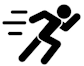

In [ ]:
# under the assumptions made above, what would the Min/Max and Std/Mean ratios be for 10,000 dimensions?

## Visualizing Sparse Data

In [ ]:
# show visually that same distance over greater dimensions
# leads to sparser data

# don't worry about all the plotting logic - just absorb the sparsity idea

# plotly is charting library - good for 3d
import plotly.graph_objects as go
# let's us do more complex math
import math

# define data points with x, y, and z values
# the red points differ by 2 on 2 dimensions (x and y)
red_p1, red_p2 = [2, 2, 1], [4, 4, 1]
# the blue points differ by 2 on 3 dimensions (x and y and z)
blue_p1, blue_p2 = [5, 5, 5], [7, 7, 7]

# calculate lengths between the two reds and the two blues
red_len = math.dist(red_p1, red_p2)
blue_len = math.dist(blue_p1, blue_p2)

# calculate midpoints for placing the labels
red_mid = [(red_p1[i] + red_p2[i]) / 2 for i in range(3)]
blue_mid = [(blue_p1[i] + blue_p2[i]) / 2 for i in range(3)]

# define the 3D plot
fig = go.Figure(data=[
    # plot red line (2 dimensions differ by 2 each)
    go.Scatter3d(
        x=[red_p1[0], red_p2[0]], y=[red_p1[1], red_p2[1]], z=[red_p1[2], red_p2[2]],
        mode='lines+markers',
        line=dict(color='red', width=5), marker=dict(size=8, color='red')
    ),
    # red line add label
    go.Scatter3d(
        x=[red_mid[0]], y=[red_mid[1]], z=[red_mid[2]],
        mode='text', text=[f'Len: {red_len:.2f}'],
        textposition='top center', textfont=dict(color='red')
    ),

    # plot blue line (3 dimensions differ by 2 each)
    go.Scatter3d(
        x=[blue_p1[0], blue_p2[0]], y=[blue_p1[1], blue_p2[1]], z=[blue_p1[2], blue_p2[2]],
        mode='lines+markers',
        line=dict(color='blue', width=5), marker=dict(size=8, color='blue')
    ),
    # blue line add label
    go.Scatter3d(
        x=[blue_mid[0]], y=[blue_mid[1]], z=[blue_mid[2]],
        mode='text', text=[f'Len: {blue_len:.2f}'],
        textposition='top center', textfont=dict(color='blue')
    )
])

# configure layout
fig.update_layout(
    showlegend=False,
    scene=dict(
        xaxis=dict(title='X Axis', range=[0, 8]),
        yaxis=dict(title='Y Axis', range=[0, 8]),
        zaxis=dict(title='Z Axis', range=[0, 8])
    ),
    title="3D Lines with Length Labels"
)

# Display the interactive plot
fig.show()

## Exercise 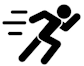

Imagine two data points each defined by (x,y,z) values had the same y and z values, but the x value for the first was 2 lower than the x value for the second. How long would the line between those 2 points be?

## Principal Component Analysis

Principal Component Analysis (PCA) finds the maximum "directions" and "amounts" of variation in a data set.

These directions (eigenvectors) and amounts (eigenvalues) are the ***"principal components"*** and do **not** correspond to individual variables - they are more like ways to summarize the variation in multiple variables.

**The Example Data**

We'll start with a simple, two-variable data set that. The x-axis will be the score on the final exam for a course and the y-axis will be the average number of hours per week the student has studied for that class. Notice that the variables are highly correlated (they move together).

There is variance in both the horizontal and vertical directions, but if you wanted to draw single line that helps "trace" most of the variance you see, it would be a diagnonal line that slopes upward to the right.

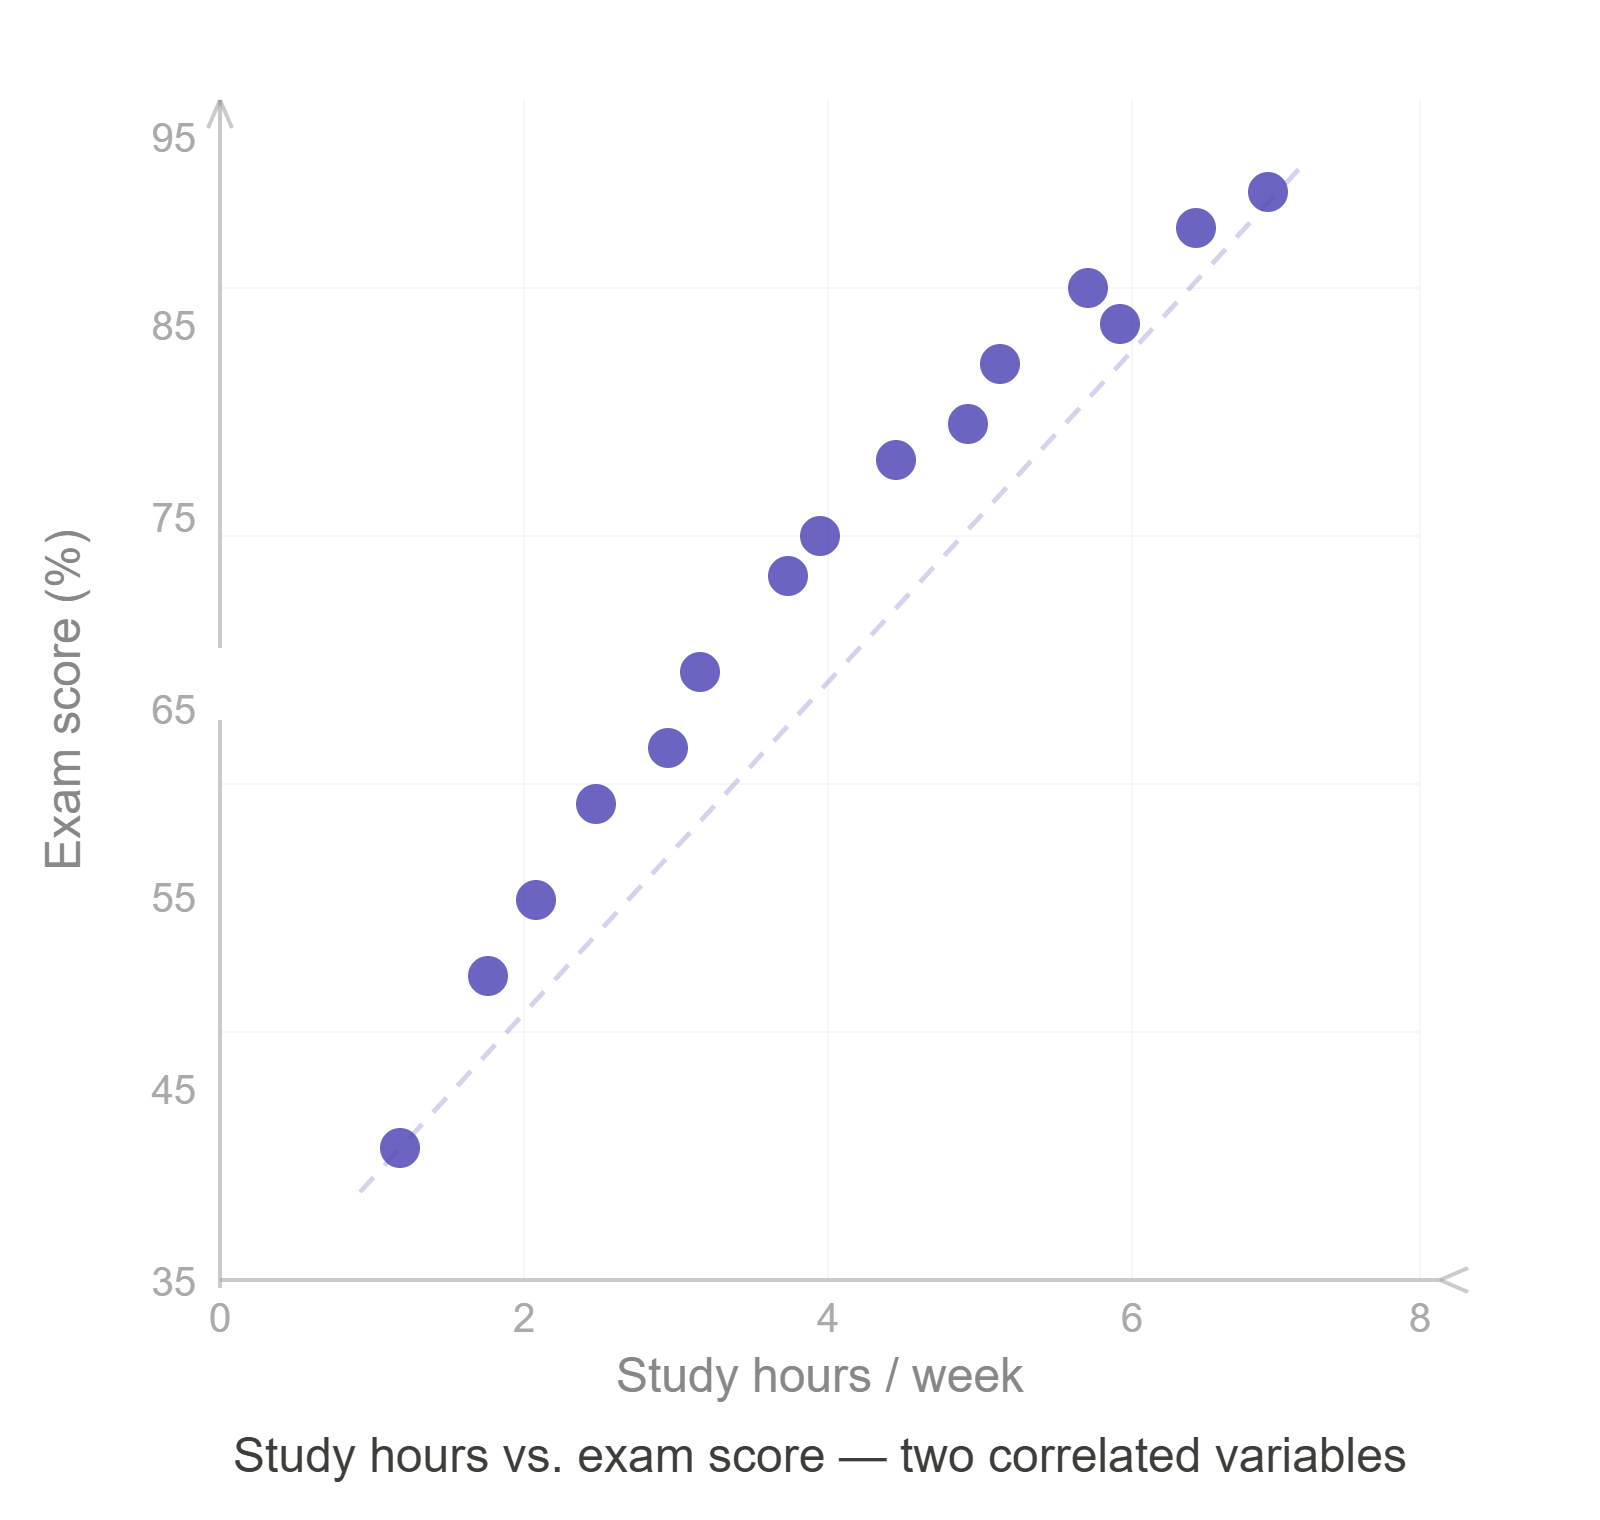

**Quick Intermission: Standardizing (Centering and Scaling)**

Exam scores go from 0 to 100, but nobody studies 100 hours a week. The variance on a number of higher scale is going to drown out the variance in variables of smaller scale, even if those variables end up being most important.

So, to use a technique like PCA, we first get all of the data on the **same scale**. That math PCA uses also requires that the data be **centered** - this means that the "center" of the data cloud is the origin (x=0,y=0,...).

***Z-score normalization*** is an often-used way to achieve this. A z-score tells you how many standard deviations above or below the mean a vale falls.

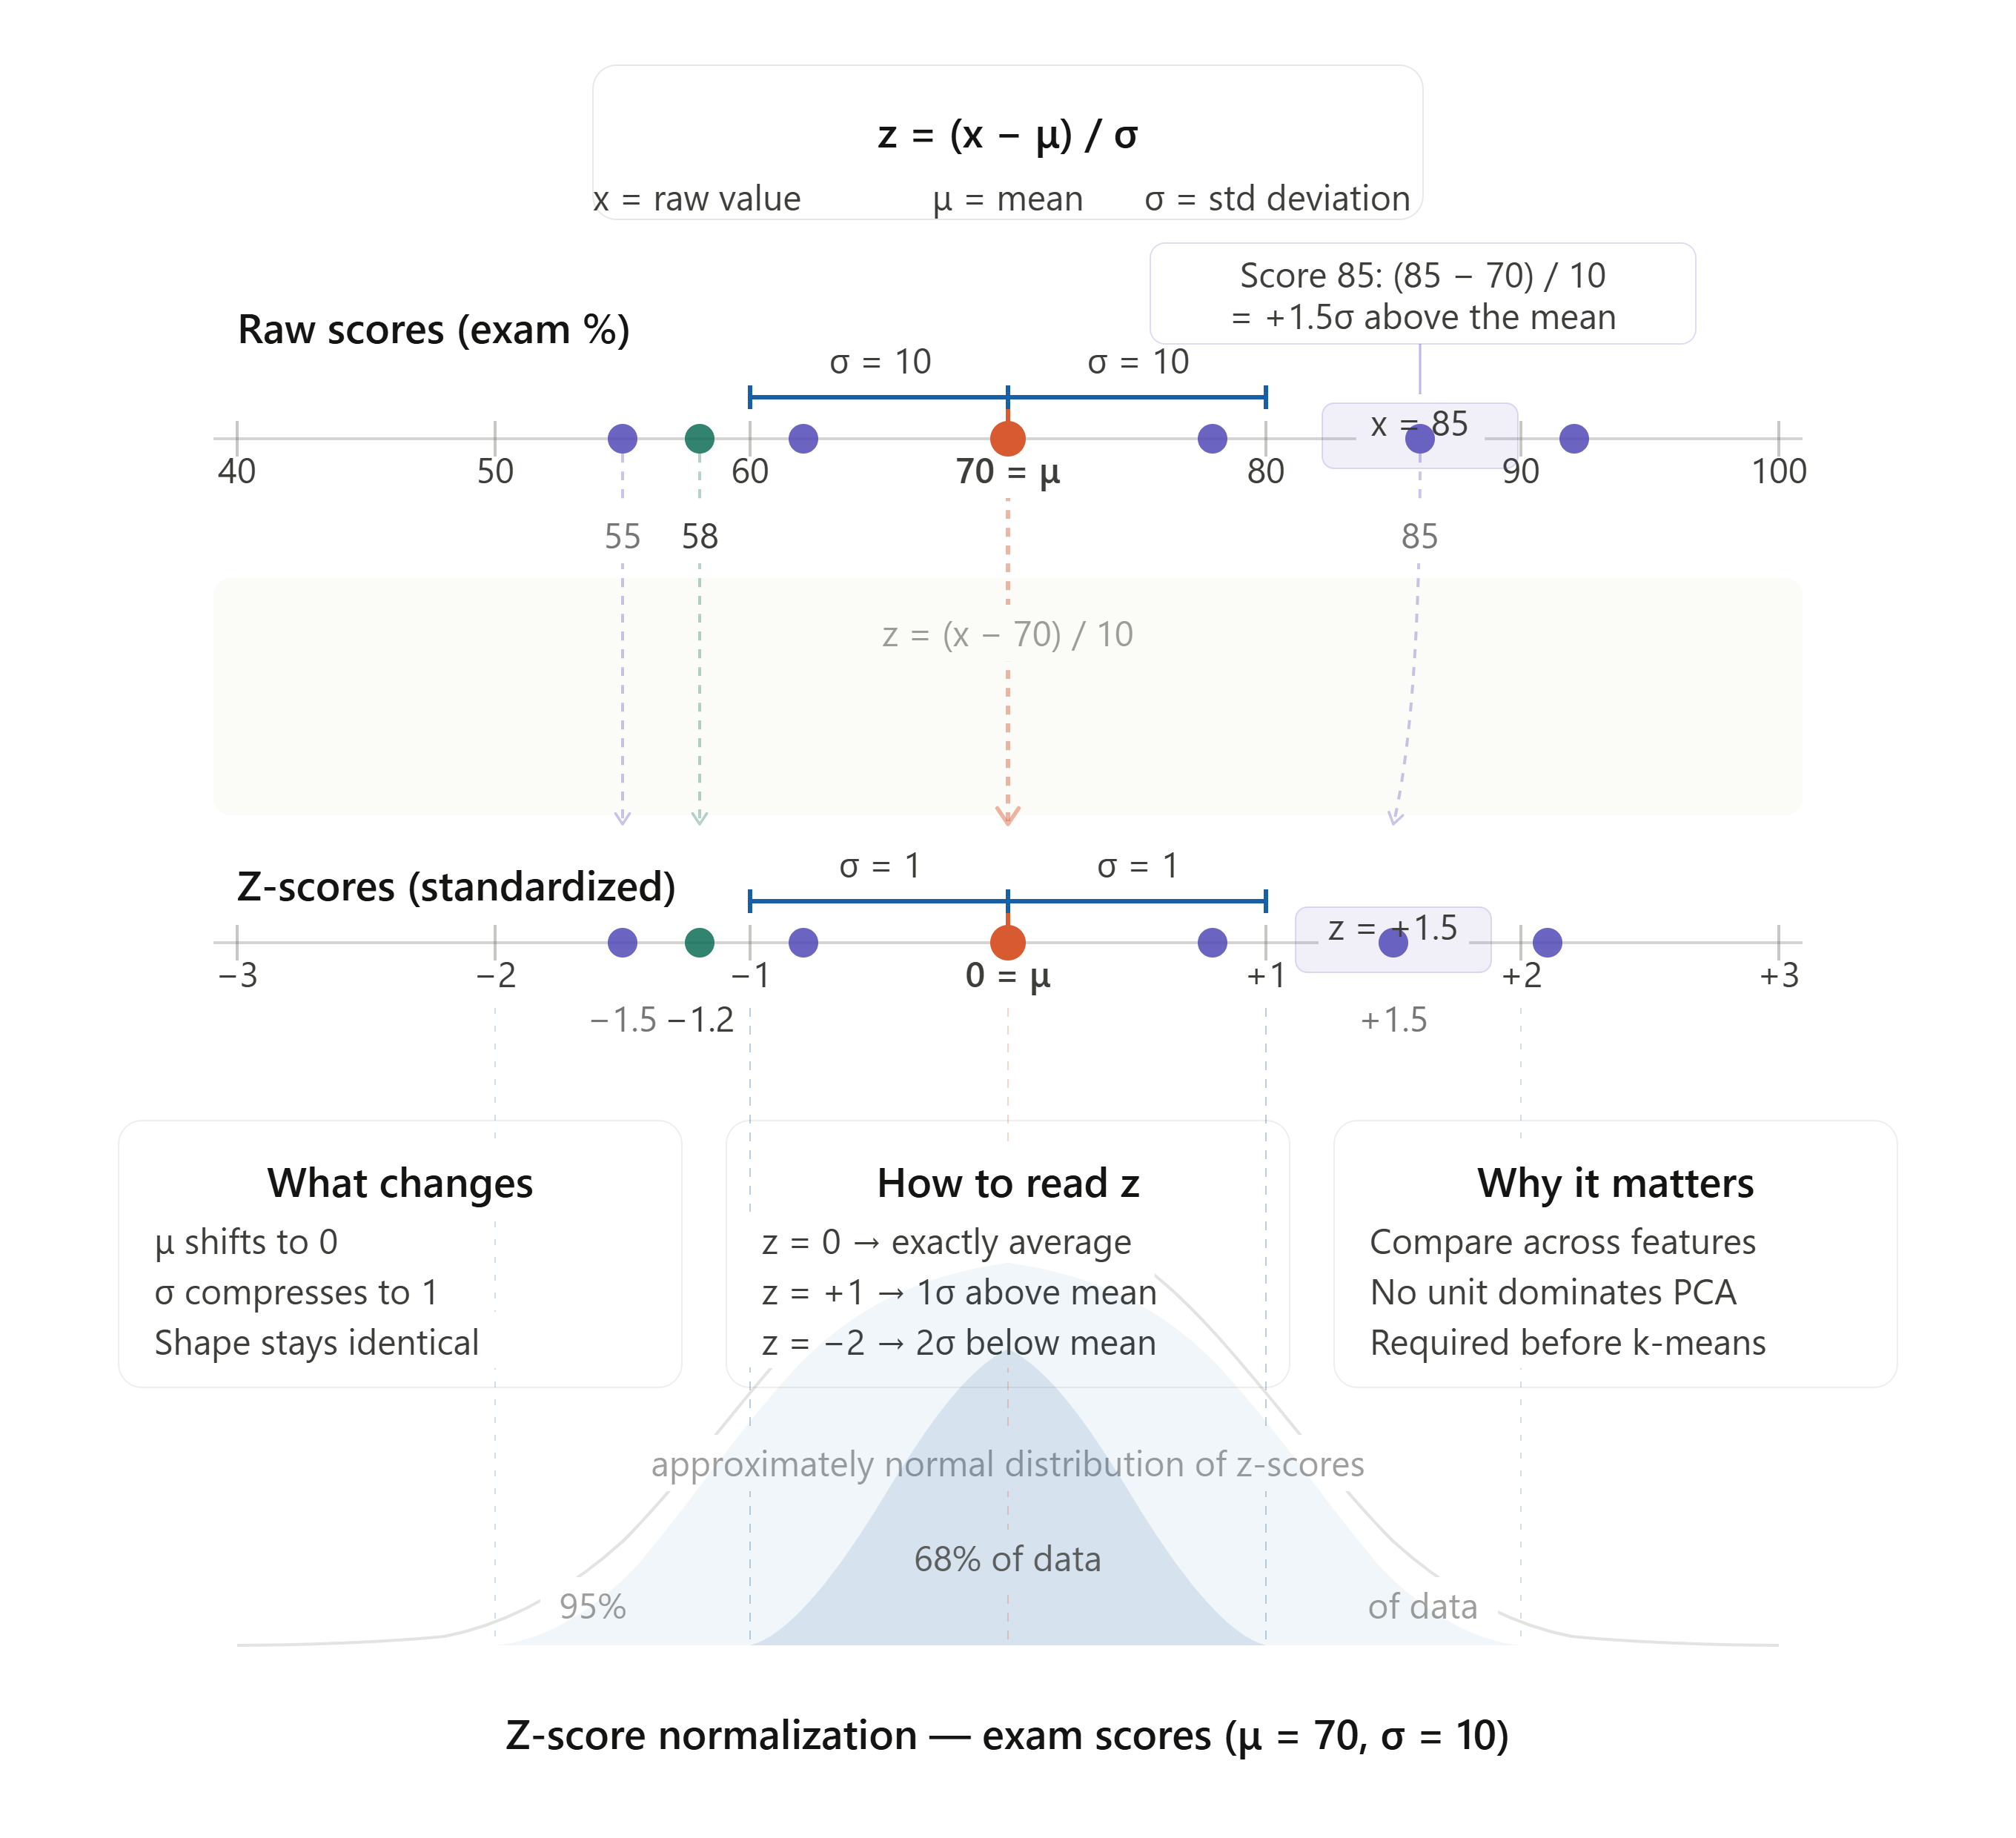

**Finding Eigenvectors and Eigenvalues**

After we center and scale (*standardize*) the data, PCA finds the directions of variance (**eigenvectors**). The first eigenvector (direction of greatest variance) is the first principal component (PC1).

The corresponding **eigenvalue** (symbolized by **λ**) for an eigenvector   tells you how much of the variance of the data set exists along that eigenvector's direction.

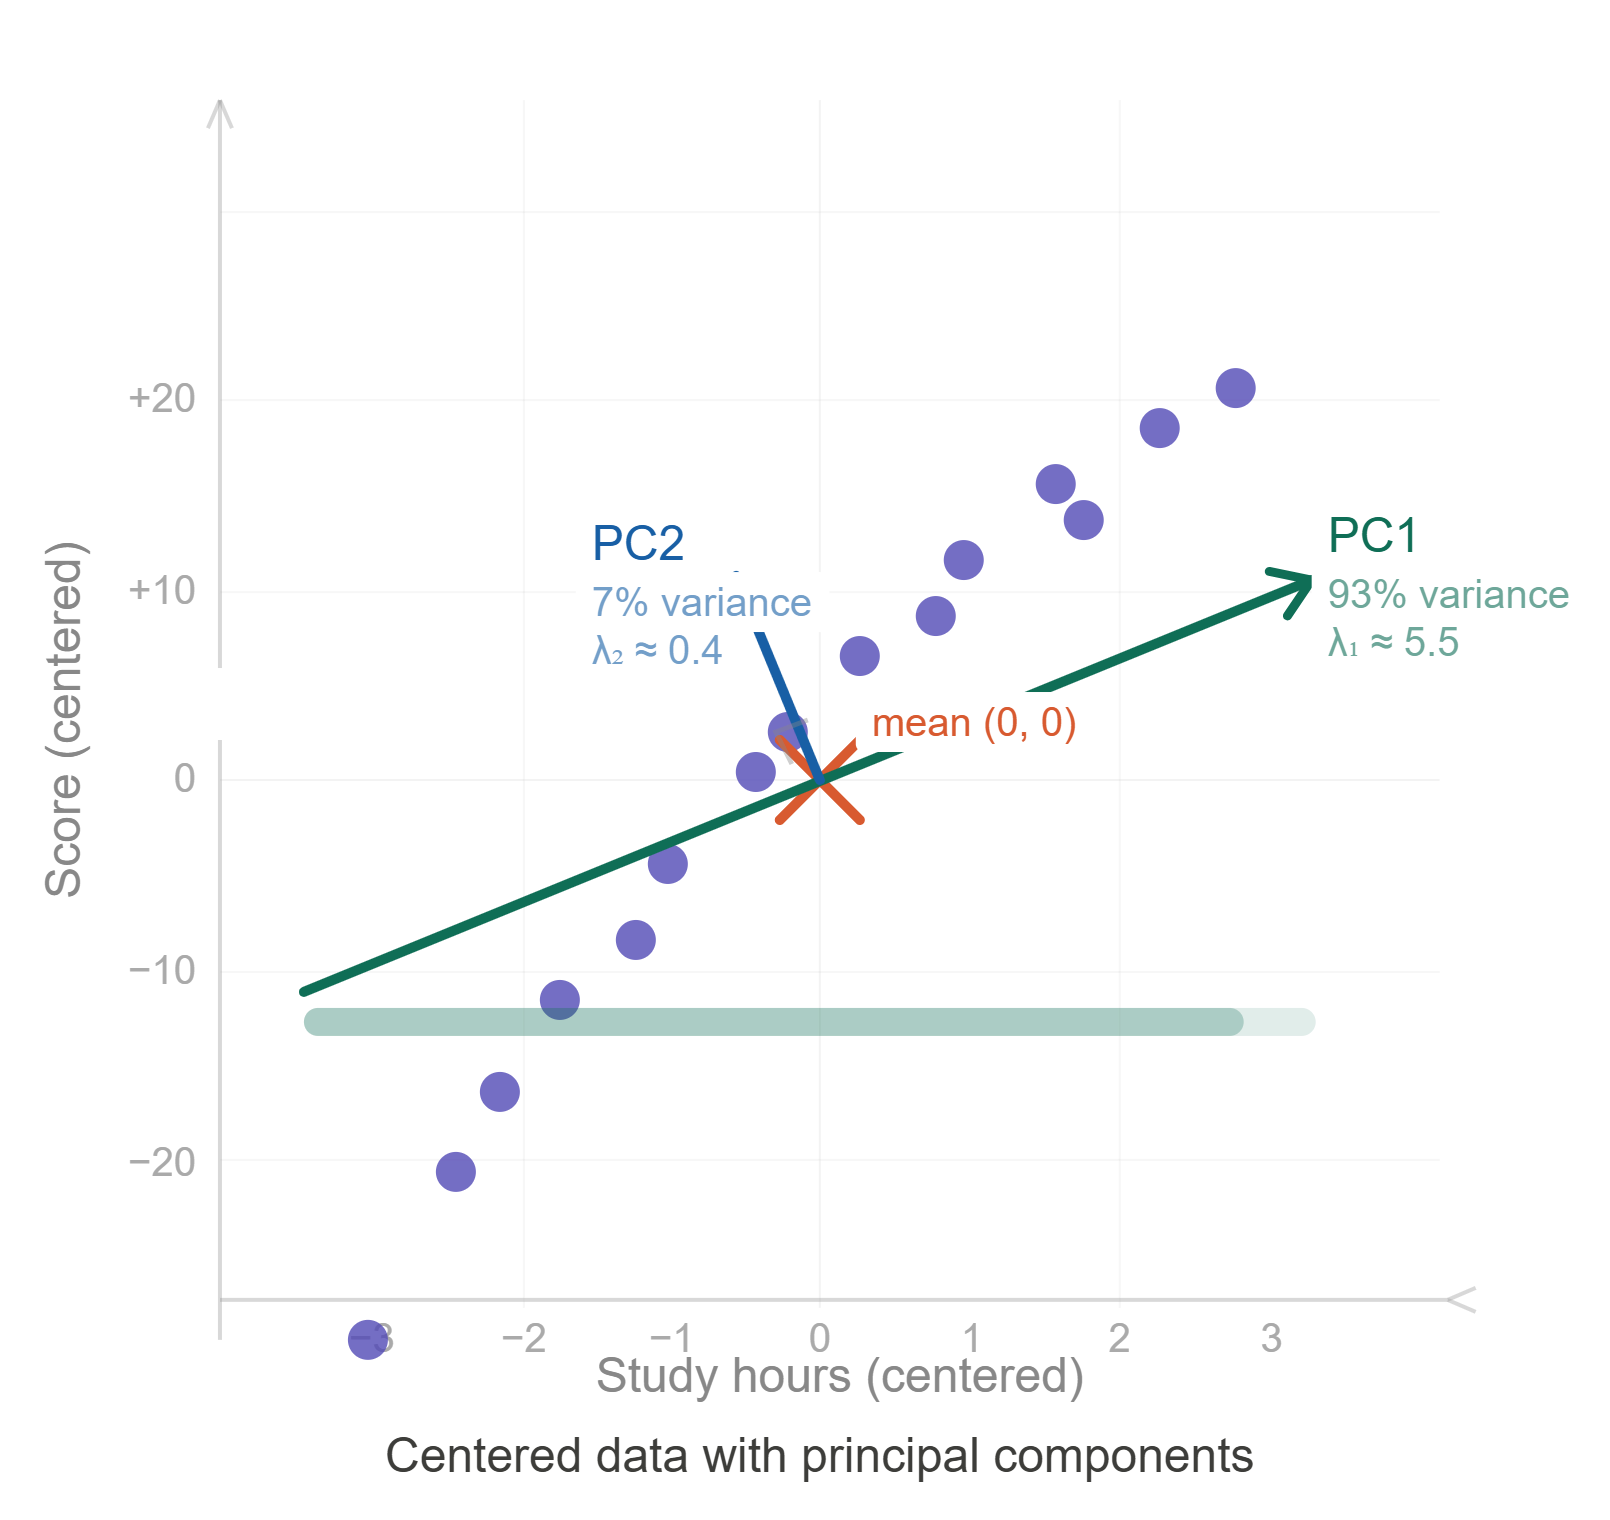

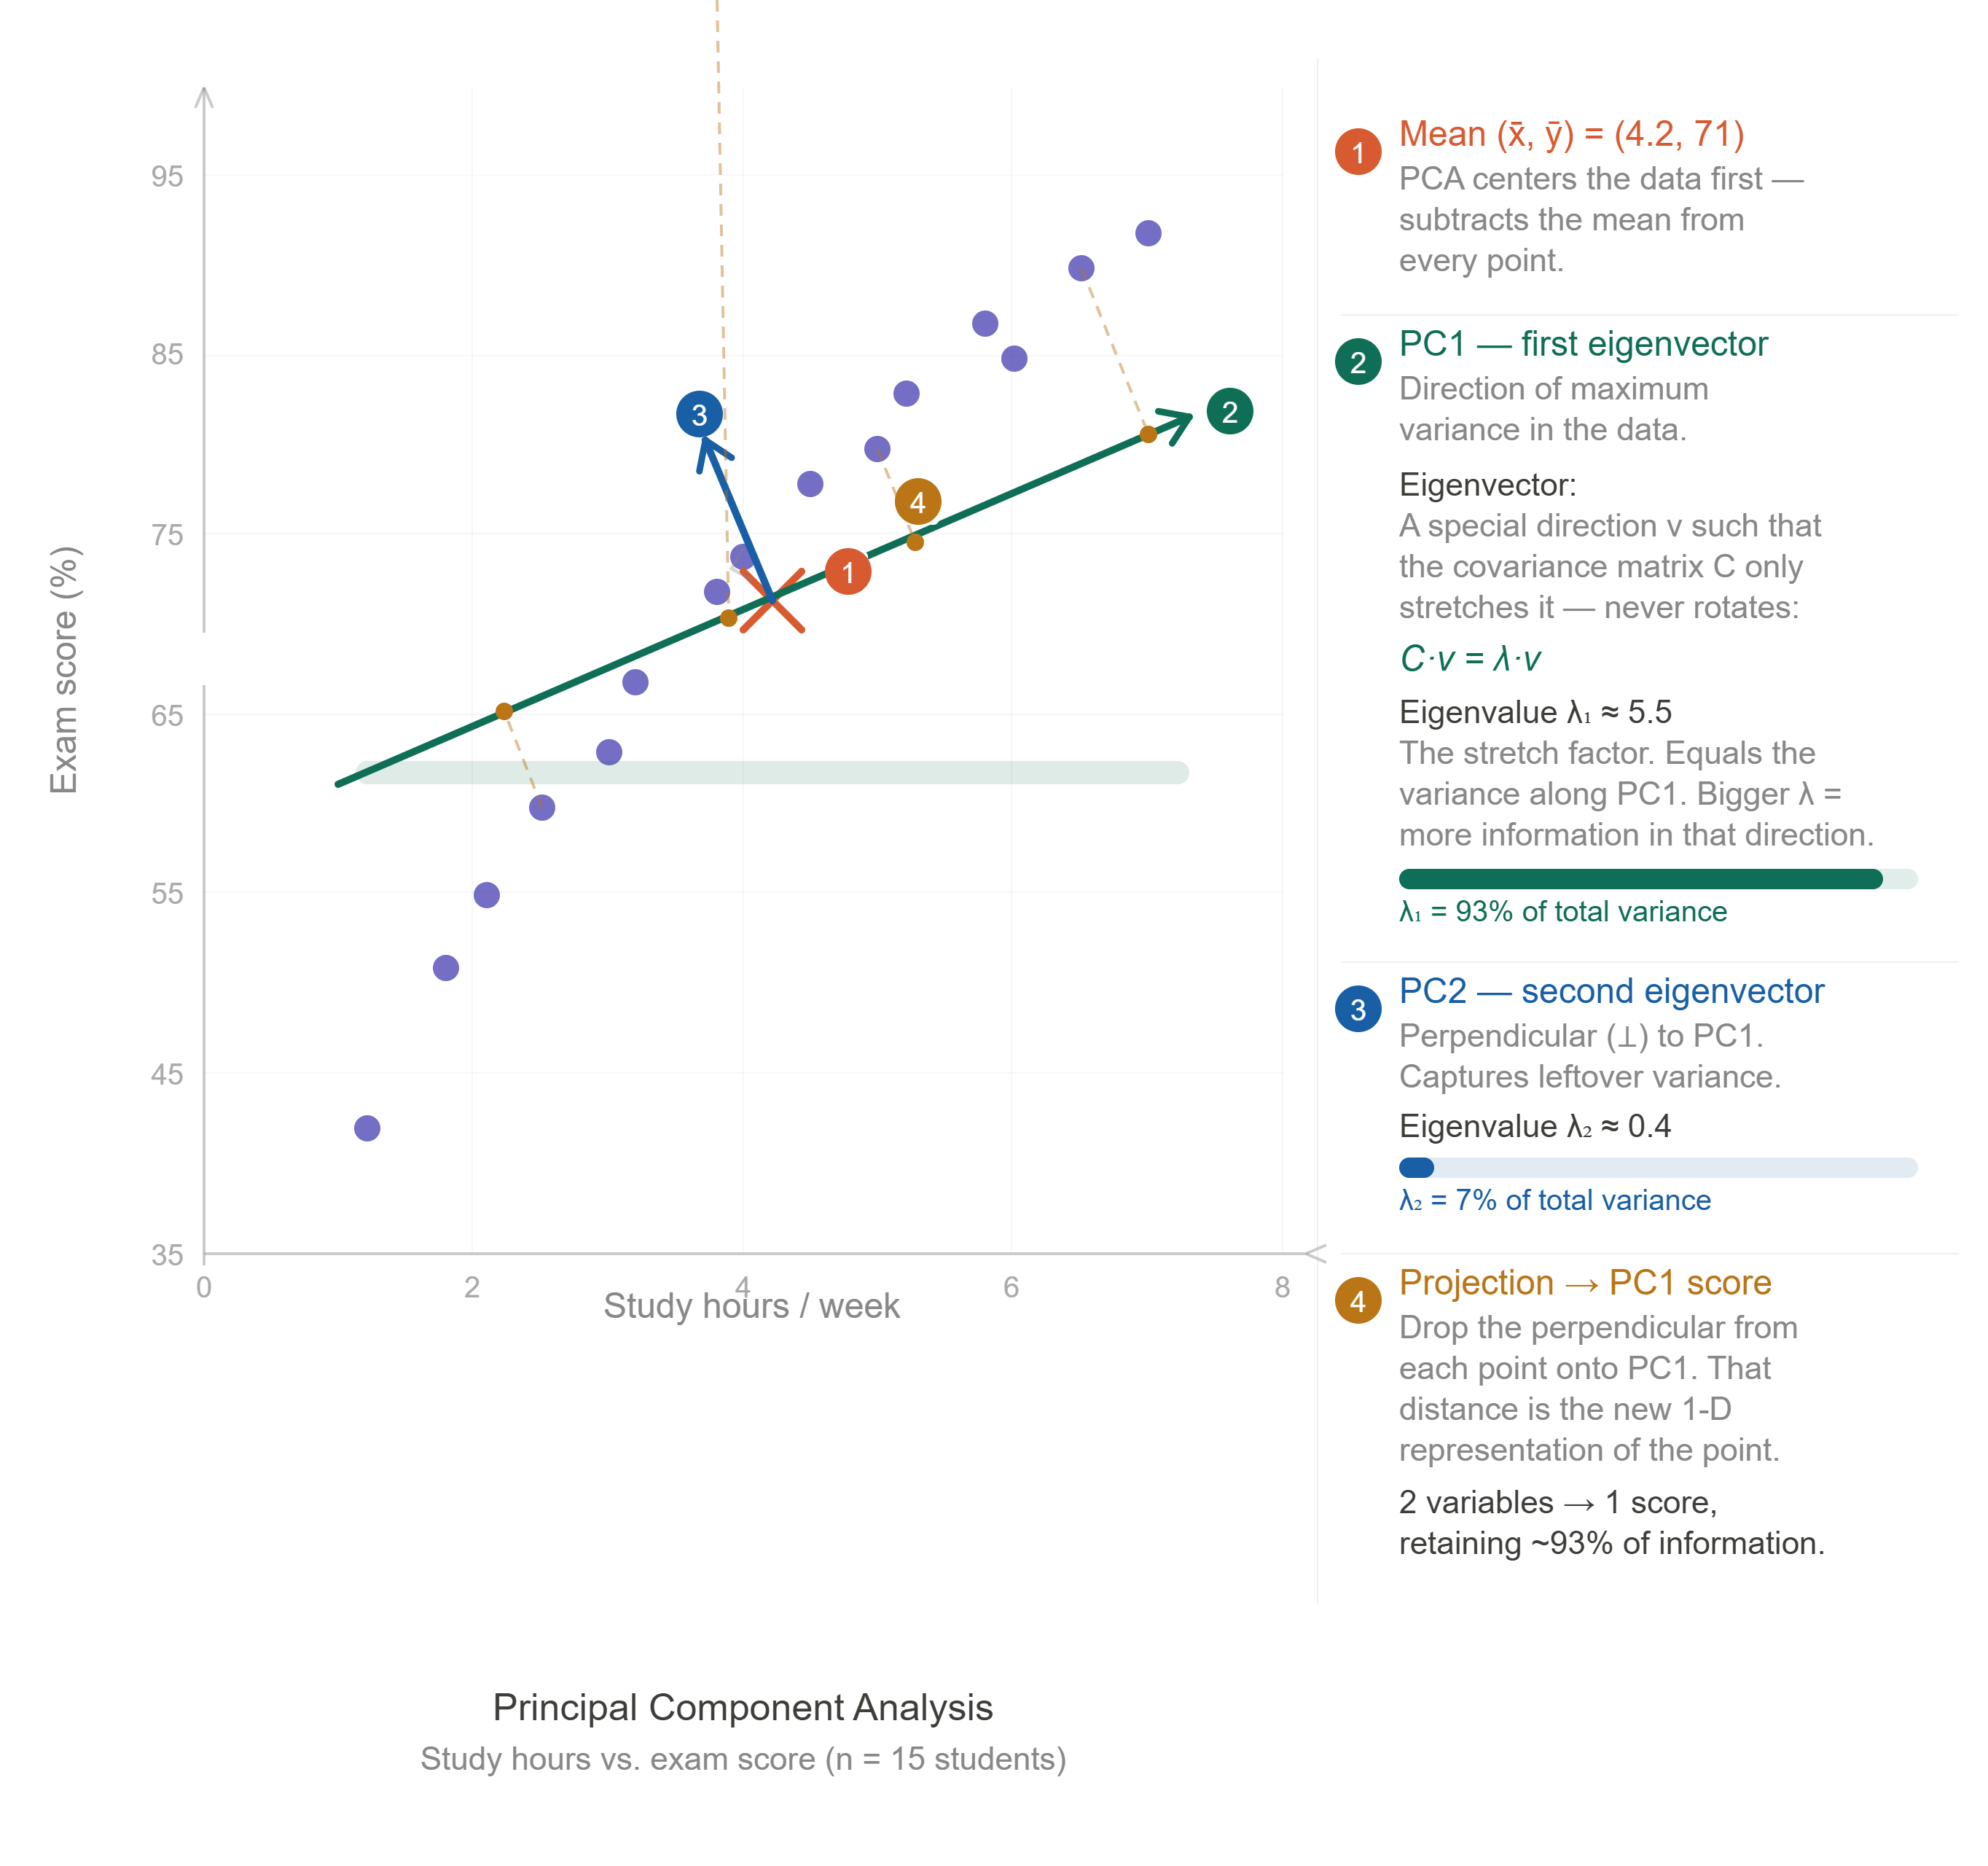

## PCA with Wine Dataset

In [ ]:
# demonstrate PCA using the famous "wine" dataset
# reduces 13 chemical features down to a handful of principal components

import pandas as pd
import matplotlib.pyplot as plt

# a scaler brings variables with different ranges onto a common scale
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# get the data and do some basic EDA
wine_df = pd.read_csv('https://raw.githubusercontent.com/stephenfrein/vucsc8491/refs/heads/main/wine.csv')
print(wine_df.shape)
display(wine_df.head())
display(wine_df.describe())

## Exercise 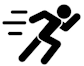

In [ ]:
# spend some time visualizing the data using any techniques you like
# try to find a way to "separate" the cultivars in a graph
# this is to identify what helps you to indentify the cultivar
# I recommend trying a 3D scatter plot from last week

Let's continue with PCA...

In [ ]:
# a cultivar is a variety of grape - let's imagine we want to predict that based on the other 13 columns
# X (predictors) will be everything but the Cultivar column
X = wine_df.drop('Cultivar', axis=1) # axis=1 means "column" here
# y (the target) will be the Cultivar column
y = wine_df['Cultivar']

In [ ]:
# think of how distance/variation would be impacted by scale of the columns
# put all of the predictor variables on the same scale
# shift mean to zero and standard deviation to one (z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# compare original to scaled data
display(X.head())
display(pd.DataFrame(X_scaled).head())

In [ ]:
# apply PCA
# reduce from 13 original features to 2 principal components

# pca object will drop data to 2 principal components
pca = PCA(n_components=2)
# find the 2 most important principal components in the predictors
X_pca = pca.fit_transform(X_scaled)

print("\nPCA-transformed data shape:")
print(X_pca.shape)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained by PC1 and PC2:")
print(pca.explained_variance_ratio_.sum())

# put results into data frame

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cultivar"] = y

print("\nFirst few PCA rows:")
print(pca_df.head())

In [ ]:
# plot PCA result

plt.figure(figsize=(8, 6))

# STEVE, explain why there's a loop here
for cultivar in wine_df['Cultivar'].unique():
    subset = pca_df[pca_df["Cultivar"] == cultivar]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=cultivar,
        alpha=0.8
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Wine Dataset: 13 Features Reduced to 2")
plt.legend(title="Cultivar")
plt.grid(True)
plt.show()

In [ ]:
# now we'll aim for a defined level of variance to be explained instead

# let PCA automatically select the number of components needed
# to explain specified proportion of variance in the data
var_explained = 0.90

# pca object will keep only as many components as needed to explain variance
pca = PCA(n_components=var_explained)
# find the minimum components to explain that variance in the predictors
X_pca = pca.fit_transform(X_scaled)

print("\nPCA-transformed data shape:")
print(X_pca.shape)

print(f"\nNumber of components selected: {pca.n_components_}")

print("\nExplained variance ratio (per component):")
print(pca.explained_variance_ratio_)

print("\nCumulative variance explained:")
print(pca.explained_variance_ratio_.cumsum())

print(f"\nTotal variance explained: {pca.explained_variance_ratio_.sum():.4f}")

# put results into data frame
# column names now depend on how many components were selected
pc_cols = [f"PC{i+1}" for i in range(pca.n_components_)]
pca_df = pd.DataFrame(X_pca, columns=pc_cols)
pca_df["Cultivar"] = y

print("\nFirst few PCA rows:")
print(pca_df.head())

In [ ]:
# now let's visualize the Cultivars in 3d using the first 3 PCs above

import plotly.express as px

# extract first 3 columns from the already-transformed X_pca
pca_3d_df = pd.DataFrame(X_pca[:, :3], columns=["PC1", "PC2", "PC3"])
pca_3d_df["Cultivar"] = y.astype(str)

# axis labels from the already-computed explained variance ratios
var = pca.explained_variance_ratio_
labels = {
    "PC1": f"PC1 ({var[0]:.1%} variance)",
    "PC2": f"PC2 ({var[1]:.1%} variance)",
    "PC3": f"PC3 ({var[2]:.1%} variance)",
}

fig = px.scatter_3d(
    pca_3d_df,
    x="PC1", y="PC2", z="PC3",
    color="Cultivar",
    labels=labels,
    title=f"Wine Dataset — First 3 Principal Components (from {(var_explained):.0%} variance PCA)",
)

fig.update_traces(marker=dict(size=5, opacity=0.8))
fig.update_layout(legend_title_text="Cultivar")

fig.show()